# Shor's factoring algorithm


We will use the quantum computer simulator we set up on problem set 2 to implement a classical simulation of Shor's factoring algorithm. The learning goal is to understand the different parts of the factoring algorithm in detail. 

We will focus on the actual quantum part. The exercises on the number theoretic aspects are optional but they can be helpful for understanding what happens in the factoring algorithm.

Note that the developing the entire simulation on your own would be quite time consuming, so we provide some routines for you and made the last part of putting together the entire factoring algorithm optional.

There is a lot of literature on educational material on this topic. For example, what was formerly known as the quiskit textbook can be found here: https://github.com/Qiskit/textbook/tree/main/notebooks/ch-algorithms# This is a collection of tutorial style jupyter notebooks, which also includes one on Shor's argorithm. 

In [1]:
# load some useful modules
import sys
sys.path.append("src")

# standard numerics and linear algebra libraries
import numpy as np  
import numpy.linalg as LA
import scipy.linalg as sciLA
# for making plots
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# measure runtimes
import time as time 

# sparse matrix functions
import scipy.sparse as sparse

# avoid typing np.XY all the time
from numpy import (array, pi, cos, sin, ones, size, sqrt, real, mod, append, arange, exp)

import math
from fractions import Fraction
import Adva_Quant_Inform as aqi # customer package
%matplotlib inline

### RSA encryption

As a warm up we implement the RSA encryption scheme. 
Write functions that, given two prime numbers $p$ and $q$ and a number $e<\phi(pq)$, generate a public and a private key.
Note that often, Carmichael's function $\lambda(pq)$ is used in instead of Euler's function. $\lambda(N)$ is defined as the smallest number $r$ for which $a^r=1\,\mathrm{mod}N)$ for all $a$ coprime to $N$. Show that the RSA scheme also works in this case.
Also write functions that use these key to encrypt and decrypt a message $m$.
Here $m$ can be a number $<pq$. To encryt an actual text you would first have to split the squence of letters into blocks that can be mapped to numbers and then encrypted blockwise. If you want to have some fun, write functions that encrypt and decrypt text letter wise, and use it to decrypt the word SHOR.

Hints: Useful functions `pow(a,b,N)` (i.e., $a^b\,\mathrm{mod}N$), `math.gcd()`.

As a testing example you may want to generate public and private keys with $p=61$, $q=53$, $e=17$ and encrypt and decrypt the message $m=65$. This is the example given on the wikipedia page on the RSA cryptosystem. Try out examples with N being a products of larger primes.  

If a third party can determine the prime factors of $N$, they can efficiently calculate the private key $d$ and thus decrypt the message. The security of the protocol thus relies on factoring being a hard problem classically. Thus, being able to factor $N$ efficiently with a quantum computer would break the RSA scheme.

In [2]:
# RSA example
p = 61
q = 53
e = 17

# message to encrypt
m = 65

# generate public modulus
N = p * q

# Carmichael function lambda(N) = lcm(p-1, q-1)
lam = (p - 1) * (q - 1) // math.gcd(p - 1, q - 1)

# private exponent d satisfies e*d = 1 mod lambda(N)
d = pow(e, -1, lam)

# encrypt and decrypt
c = pow(m, e, N)
m_decrypted = pow(c, d, N)

print("RSA key generation")
print("p =", p)
print("q =", q)
print("N = p*q =", N)
print("lambda(N) =", lam)
print("public exponent e =", e)
print("private exponent d =", d)
print("check e*d mod lambda(N) =", (e * d) % lam)

print("\nEncryption")
print("message m =", m)
print("ciphertext c = m^e mod N =", c)

print("\nDecryption")
print("decrypted message = c^d mod N =", m_decrypted)
print("decryption successful?", m_decrypted == m)

RSA key generation
p = 61
q = 53
N = p*q = 3233
lambda(N) = 780
public exponent e = 17
private exponent d = 413
check e*d mod lambda(N) = 1

Encryption
message m = 65
ciphertext c = m^e mod N = 2790

Decryption
decrypted message = c^d mod N = 65
decryption successful? True


### Success of the factoring algoithm

In the factoring algorithm, given a number $N$ of which we want to find a factor, one randomly picks a number $1<x<N$ that is coprime with $N$ and determines its order mod $N$. (In fact, we randomly pick a number $1<x<N$ and check if it is coprime wih N. If not, we have aready found a factor of N and can stop.) If the order $r$ is even and the root of $x^{r/2}\neq -1$, then either $x^{r/2}+1$ or $x^{r/2}-1$ must have a common factor with $N$. Hence by calculating $\mathrm{gcd}(x^{r/2}+1,N)$ and $\mathrm{gcd}(x^{r/2}-1,N)$ we find a factor of $N$ and the algorithm succeeds. Here we want to explore for how many randomly chosen $x$ these conditions are fulfilled, thereby learning something about the structure of the multiplicative group of coprimes with $N$. 

- Write a function that finds the order of $x$ mod $N$ in a brute force way (just iteratively multiplying $x$ with itself mod $N$ until one gets 1). This part will in the end be done on the quantum computer.
- Check for how many of the numbers coprime with $N$ does $x^{r/2}\pm 1\, \mathrm{mod}\, N$ have a common factor with $N$, i.e. the factoring algorithm succeeds. Use small $N$ which are a product of two primes for checking, e.g. $N=91$.

In [3]:
N=91
ncoprime=0
nsuccess=0
for x in range(1,N):
    #print(x, try_find_factors(x,N))
    if not isinstance(aqi.operators.try_find_factors(x,N), str):
        nsuccess += 1
    if  math.gcd(x,N)==1:
        ncoprime += 1

print(nsuccess, 'out of', ncoprime, 'coprime choices worked')
print('I.e. in only ', 100*(ncoprime - nsuccess)/(N-2), '% of the reasonable choices of x, the classical part of the factoring algorithm failed.')
# print(find_order_brute_force(10,N))
# print(pow(10,6//2,N))


72 out of 72 coprime choices worked
I.e. in only  0.0 % of the reasonable choices of x, the classical part of the factoring algorithm failed.


### The quantum Fourier transform

We now come to the quantum part of the algorithm. The first crucial ingredient of the quantum order finding algorithm is the inverse quantum Fourier transform. 

Below we provide some functions you might have developed in similar form on problem set 2, and which might be useful in the following.

#### (a) Building swap gates and controlled phase gates

- Write a function that builds controlled $R_k$ gates between two arbitrary quibits in a register (using sparse matrices), similar to the CNOT gate you implemented on problem set 2. The single qubit $R_k$ gate is provided above but keep in mind that for the inverse QFT you need $R_k^{-1}=R_k^\dagger$.
- Write a function that builds swap gates between pairs of qubits. Note that a swap gate on two qubits can be written as $U_{\textrm{swap}} = |00\rangle\langle 00|+|01\rangle\langle 10|+|10\rangle\langle 01|+|11\rangle\langle 11|$.

#### (b) Fourier transform

Implement the inverse quantum Fourier transform (iQFT). 

Instructions:

Write a function that takes as input the state of the register (i.e. the coefficient vector in the computational basis), sequentially applies all gates of the iQFT circuit, and outputs the final state (coefficient vector) again.
We don't want to build the whole iQFT as a unitary matrix as this matrix would be dense and take up a lot of memory. Applying it to a state would scale as $(2^n)^2$. The sequential application of the $O(n^2)$ sparse gates results in a $O(n^2 2^n)$ scaling, thus you have implemented a version of a classical (inverse) fast Fourier transform!

For the order finding algorithm we will need to apply the iQFT only to the first register. 
Thus, your iQFT function should allow you to apply it only to the first $n_1$ qubits of an $n$-qubit register and leave the remaining qubits alone, i.e. is the identity on the remaining qubits.

Note: In the order finding algorithm, the qubits will be measured right after the iQFT. Thus, as shown on Problem set 3.1, it would be sufficent to measure the qubits sequentially and feed forward the result. This would enable to simulate this part of the order finding algorithm more efficiently, and only using single qubit gates.

In [4]:
# Test inverse QFT on one basis state
n = 4
Psi = aqi.operators.basisvec(n, 8)
phase_result = (1 / (2 * pi)) * np.angle(aqi.operators.apply_invQFT(n, Psi)) % 1

print("Inverse QFT phase test =", "n =", n)
print("input basis index = 8")
print("phase result\n", np.round(phase_result, 4))


# Test inverse QFT on only the first register
n1 = 2
n2 = 2
n = n1 + n2

print("\nInverse QFT on first register test")
print("n1 =", n1)
print("n2 =", n2)
print("total qubits =", n)

for i in range(2**n):
    Psi = aqi.operators.basisvec(n, i)
    result = aqi.operators.apply_invQFT_reg1(n1, Psi)

    print("\ninput basis index", i)
    print(np.round(result, 10))


# Compare QFT and inverse QFT matrices
n = 3

QFT = aqi.operators.build_QFT(n)
invQFT = aqi.operators.build_invQFT(n)

print("QFT phase matrix\n", (1 / (2 * pi)) * np.angle(QFT.toarray()) % 1)
print("Inverse QFT phase matrix\n", (1 / (2 * pi)) * np.angle(invQFT.toarray()) % 1)

identity_test = (QFT @ invQFT).toarray()

print("QFT @ invQFT\n", np.round(identity_test, 10))
print("Is QFT @ invQFT equal to identity?", np.allclose(identity_test, np.eye(2**n)))

Inverse QFT phase test = n = 4
input basis index = 8
phase result
 [0.  0.5 0.  0.5 0.  0.5 0.  0.5 0.  0.5 0.  0.5 0.  0.5 0.  0.5]

Inverse QFT on first register test
n1 = 2
n2 = 2
total qubits = 4

input basis index 0
[0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j
 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j]

input basis index 1
[0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j
 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j]

input basis index 2
[0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j
 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j]

input basis index 3
[0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j
 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]

input basis index 4
[ 0.5+0.j   0. +0.j   0. +0.j   0. +0.j   0. -0.5j  0. +0.j   0. +0.j
  0. +0.j  -0.5+0.j   0. +0.j   0. +0.j   0. +0.j  -0. +0.5j  0. +0.j
  0. +0.j   0. +0.j ]

input ba

### Quantum order finding

The second ingredient of the order finding algorithm is the modular multiplication gate: $U:\,|y\rangle \mapsto |xy \,\mathrm{mod}\, N\rangle$ (for $y< N$) in second register controlled by some qubit in the first register. For $y\geq N$, $U$ is the identity. This is the "padding" we need since $N$ will not be a power of two. $U^{2^j}$ gates are applied to the second register controlled by the state of qubit $j$ in the first register. When doing this on an actual quantum computer this step would be accomlished by implementing modular exponentiation with reversible classical gates. This requires $O(L^3)$ gates (where $L$ is the number of binary digits of $N$) classically through repeated squaring. 
This is actually the bottleneck of the factoring algorithm and constructing the classical reversible circuits is not trivial.

Here we will make our life easy and directly implement the collective action of the controlled $U^{2^j}$ gates, which is the unitary $U_x :|z\rangle|y\rangle \mapsto |z\rangle|x^zy \,\mathrm{mod}\, N\rangle$ for $y< N$ and $|z\rangle|y\rangle \mapsto |z\rangle|y\rangle$ otherwise. 

#### (a) Modular exponentiation gate

Below you are provided a function that builds the operation $U_x$ as a sparse matrix. The inputs are the number of qubits $t$ in the first register and the integer numbers $x$ and $N$. The resulting matrix only has one non-zero entry in each row. Let us explain more precisely what the structure of the matrix $U_x$ is: It is block diagonal. For a fixed state $|z\rangle$ of the 1st register, there is a $2^L \times 2^L$ block ($L$ being the size of the second register) spanned by the all possible states $| y \rangle$ of the second register. Within each such block in each row there is one non-zero matrix element (with value 1) at position (column) $x^zy \,\mathrm{mod}\, N$ (for $y<N$) with respect to the beginning of the block. For $y\geq N$ the non-zero entry is on the diagonal. 

Make sure you understand how the construction of the $U_x$ gate works and test it for some examples where you can compute the positions of the non-zero matrix elements by hand to test the implemenation.

In [5]:
# testing
t = 4
x = 2
N = 15

U = aqi.operators.build_x_tothe_z(t, x, N)
print("U=", U)
print("Operator shape =", U.shape)
print("Operator type =", type(U))
print("gcd=", math.gcd(x, N))

U=   (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
  (5, 5)	1.0
  (6, 6)	1.0
  (7, 7)	1.0
  (8, 8)	1.0
  (9, 9)	1.0
  (10, 10)	1.0
  (11, 11)	1.0
  (12, 12)	1.0
  (13, 13)	1.0
  (14, 14)	1.0
  (15, 15)	1.0
  (16, 16)	1.0
  (17, 24)	1.0
  (18, 17)	1.0
  (19, 25)	1.0
  (20, 18)	1.0
  (21, 26)	1.0
  (22, 19)	1.0
  (23, 27)	1.0
  (24, 20)	1.0
  :	:
  (231, 237)	1.0
  (232, 226)	1.0
  (233, 230)	1.0
  (234, 234)	1.0
  (235, 238)	1.0
  (236, 227)	1.0
  (237, 231)	1.0
  (238, 235)	1.0
  (239, 239)	1.0
  (240, 240)	1.0
  (241, 242)	1.0
  (242, 244)	1.0
  (243, 246)	1.0
  (244, 248)	1.0
  (245, 250)	1.0
  (246, 252)	1.0
  (247, 254)	1.0
  (248, 241)	1.0
  (249, 243)	1.0
  (250, 245)	1.0
  (251, 247)	1.0
  (252, 249)	1.0
  (253, 251)	1.0
  (254, 253)	1.0
  (255, 255)	1.0
Operator shape = (256, 256)
Operator type = <class 'scipy.sparse._csr.csr_matrix'>
gcd= 1


In [6]:
# testing build_x_tothe_z

t = 10
x = 5
N = 27

L = aqi.operators.qubits_for_number(N)
n = t + L

U = aqi.operators.build_x_tothe_z(t, x, N)

z = 3
y = 1

input_index = z * 2**L + y
expected_y = (y * pow(x, z, N)) % N
expected_index = z * 2**L + expected_y

psi = aqi.operators.basisvec(n, input_index)
result = U @ psi

print("L =", L)
print("n =", n)
print("Operator shape =", U.shape)
print("z =", z)
print("y =", y)
print("expected y*x^z mod N =", expected_y)
print("input index =", input_index)
print("expected output index =", expected_index)
print("actual output index =", result.argmax())
print("test passed =", result.argmax() == expected_index)

L = 5
n = 15
Operator shape = (32768, 32768)
z = 3
y = 1
expected y*x^z mod N = 17
input index = 97
expected output index = 113
actual output index = 113
test passed = True


#### (b) The order finding algorithm put together

Now implement the quantum order finding algorithm (excluding the final measurement) and use it to find the order of 7 mod 15 and of 2 mod 21. Inputs: t, x, N. Output: The final state of the circuit. 

Analyse the output state: In what states can each one of the registers end up? Visualize the probability distribution over the outcome states. Interpret and discuss your results! The code snippets below give you some ideas on how to do this. 

Try out different $t$ to see how many qubits are needed in the 1st register to get reliable results. Try to verify the expected behavior: In the case $N=15$ the order finding algorithm always gives the exact result because the order is a power of 2. For $N=21$ this is not always the case (what orders $r$ can appear?), meaning that the peaks in the probability distribution over the predicted phases becomes broader when $t$ is decreased.

When the denominator of $s/r$ is not a power of two, the phase can only be estimated approximately. In this case the continued fraction algorithm is used to find the the closest rational with denominator $<N$ from the output $b/2^t$ of the order finding algorithm. Check for which outputs $b$ the correct order $r$ is found. 

The continued fraction algorithm is in principle straight forward to implement (we provide an example at the end of this problem set) but you can as well use the function Fraction() from the fractions module, as done in the snippet below.

In [7]:
N = 21
t = 8
x = 2

psi = aqi.operators.find_order(t, x, N)
r = aqi.operators.find_order_brute_force(x, N)
a = pow(x, r // 2, N)

print("N =", N)
print("x =", x)
print("order r =", r)
print("x^(r/2) mod N =", a)

print("factor 1 =", math.gcd(a - 1, N))
print("factor 2 =", math.gcd(a + 1, N))
print("find factors result =", aqi.operators.try_find_factors(x, N))

N = 21
x = 2
order r = 6
x^(r/2) mod N = 8
factor 1 = 7
factor 2 = 3
find factors result = [7, 3]


Some observations

For the example of factoring 15 the order is a power of 2, so the phase to be estimated always comes out exactly. In this case one can get along with much less than 2L+1 qubits in the first register...

The case N=21 is much more interesting: The order is typically 6, so s=0...5 ocuurs. In the cases s=0 and 3 the phase estimation is exact since s/r is a power of 2. Else there is a dirstribution of phases around s/r. In the cases s=2,4 s and r have a common divisor and the algorithm fails for s=1,5 it finds the correct order. Again the error probability of the phase estimation is still acceptable for $t\ge9$.

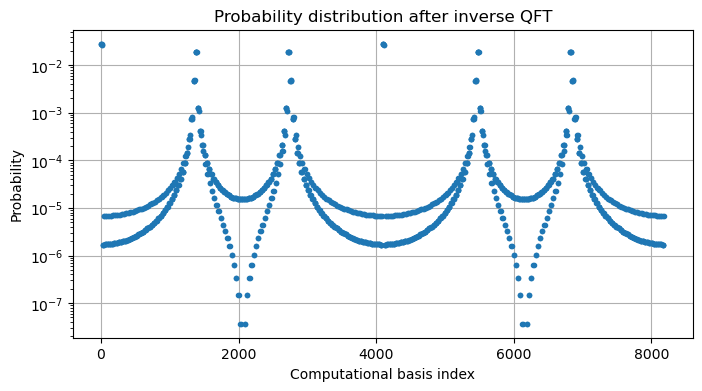

Nonzero peak indices = [   1    2    4    8   11   16 1377 1378 1380 1384 1387 1392 2721 2722
 2724 2728 2731 2736 4097 4098 4100 4104 4107 4112 5473 5474 5476 5480
 5483 5488 6817 6818 6820 6824 6827 6832]
First register outcomes k = [  0   0   0   0   0   0  43  43  43  43  43  43  85  85  85  85  85  85
 128 128 128 128 128 128 171 171 171 171 171 171 213 213 213 213 213 213]
Second register outcomes = [ 1  2  4  8 11 16  1  2  4  8 11 16  1  2  4  8 11 16  1  2  4  8 11 16
  1  2  4  8 11 16  1  2  4  8 11 16]
Peak probabilities = [0.0282 0.0282 0.0282 0.0282 0.0269 0.0269 0.0192 0.0192 0.0192 0.0192
 0.0186 0.0186 0.0192 0.0192 0.0192 0.0192 0.0186 0.0186 0.0282 0.0282
 0.0282 0.0282 0.0269 0.0269 0.0192 0.0192 0.0192 0.0192 0.0186 0.0186
 0.0192 0.0192 0.0192 0.0192 0.0186 0.0186]
Total probability in selected peaks = 0.7893706024875677

Continued fraction estimates from first register:
k = 0 k/2^t = 0/256 ≈ 0/1 order guess r = 1
k = 0 k/2^t = 0/256 ≈ 0/1 order guess r = 1
k = 0 

In [8]:
# Analyze output state from order-finding algorithm
Probs = np.abs(psi)**2

# Plot probability distribution
plt.figure(figsize=(8, 4))
plt.semilogy(Probs, ".")
plt.xlabel("Computational basis index")
plt.ylabel("Probability")
plt.title("Probability distribution after inverse QFT")
plt.grid(True)
plt.show()

# Find peaks by rounding small probabilities to zero
indNZ = np.nonzero(np.round(Probs, 2))[0]

L = aqi.operators.qubits_for_number(N)

# First-register outcomes
indNZ_reg1 = indNZ // 2**L

# Second-register outcomes
indNZ_reg2 = indNZ % 2**L

print("Nonzero peak indices =", indNZ)
print("First register outcomes k =", indNZ_reg1)
print("Second register outcomes =", indNZ_reg2)
print("Peak probabilities =", np.round(Probs[indNZ], 4))
print("Total probability in selected peaks =", np.sum(Probs[indNZ]))

print("\nContinued fraction estimates from first register:")
for k in indNZ_reg1:
    frac = Fraction(int(k), 2**t).limit_denominator(N)
    print(
        "k =", int(k),
        "k/2^t =", f"{int(k)}/{2**t}",
        "≈", f"{frac.numerator}/{frac.denominator}",
        "order guess r =", frac.denominator
    )

# Example: nearest rational number with denominator <= N
original = Fraction(33, 256)
frac = original.limit_denominator(15)

print("\nExample continued fraction approximation:")
print("Original fraction =", original)
print("Simple fraction =", frac)
print("numerator =", frac.numerator)
print("denominator =", frac.denominator)
print("decimal value =", frac.numerator / frac.denominator)

# Correct equality checks
print("Is frac equal to numerator/denominator?", frac == Fraction(frac.numerator, frac.denominator))
print("Is original exactly equal to simple fraction?", original == frac)
print("Approximation error =", abs(float(original) - float(frac)))

### Factoring algorithm 

Now we want to put the whole factoring algorithm together, including measurements.

The functions and pseudocode below will help you with this.

Use your algorithm to factor 21. Play around and try larger numbers and vary the size of the 1st register. How far can you get in terms of the size of N?

Hint: To speed up you simulation you can "cheat" and run the order finding algorithm only once for a given $x$ and use the resulting probability distribution to repeatedly do measurements without re-evaluating the circuit.

```
factoring(inputs):
    determine the size of the second register
    while no factor was found try different values of x
        check if x is coprime with N (if not, then we already have a factor)
        run the order finding algorithm, including the final measurement
        using the result in the first register, use continued fraction to get a guess for r
        while r is not yet the order (and some maximal number of trials has not been exceeded)
            run the order finding algorithm again to get a second estimate r2 for the order
            r=lcm(r, r2)
        if the conditions r even and x^(r/2)!=-1 mod N are fulfilled
            return gcd(x^(r/2) + 1, N) or gcd(x^(r/2) + 1, N) Success!
```

In [9]:
aqi.operators.factoring(91,10,22,4) #aqi.operators.

Trying order finding with x = 22
Most likely state index: 1
Maximum probability: 0.11154556274414022
The first register was measured in state [1 0 1 0 1 0 1 0 1 1] i.e. k = 683
Continued fraction gave s = 2 , r = 3
Order was found: 3
r was odd, try different x
Trying order finding with x = 23
Most likely state index: 1
Maximum probability: 0.027886390686035056
The first register was measured in state [0 0 1 0 1 0 0 1 1 0] i.e. k = 166
Continued fraction gave s = 6 , r = 37
The first register was measured in state [0 1 0 1 0 1 0 1 0 1] i.e. k = 341
Continued fraction gave s = 1 , r = 3
The first register was measured in state [0 0 0 0 0 0 0 0 0 0] i.e. k = 0
Measured k = 0, trying again
The first register was measured in state [1 1 0 1 0 1 0 1 0 1] i.e. k = 853
Continued fraction gave s = 5 , r = 6
Order was found: 222
Success! A factor was found!


7

### Optional: Continued fraction algorithm

Here is a "manual" implementation of the continued fraction expansion, i.e. a function that takes as input a real number phi and returns a rational approximation of it. The function takes an additional integer input that specifies the maximal value of the denominator of the approximating fraction (i.e. the requested precision). Playing with this may help you to deepen your understanding of continued fractions.

In [10]:
# testing:
# a rational number
phi = 251 / 2048 
max_denom = 200

print("phi =", phi)
print("max denominator =", max_denom)

frac = aqi.operators.cont_frac(phi, max_denom)
print("continued fraction =", frac)

value = aqi.operators.eval_contfrac(frac)
print("continued fraction value =", value)

num, den = aqi.operators.eval_contfrac_rational(frac)
print("rational approximation =", num, "/", den)

frac2 = Fraction(251, 2048).limit_denominator(max_denom)
print("Python Fraction result =", frac2.numerator, "/", frac2.denominator)

print("Are they equal?", num == frac2.numerator and den == frac2.denominator)

phi = 0.12255859375
max denominator = 200
continued fraction = [0, 8, 6, 3]
continued fraction value = 0.12258064516129033
rational approximation = 19 / 155
Python Fraction result = 19 / 155
Are they equal? True
